# Objectif du notebook 

Date de création : 27/03/2026

In [1]:
import os
import sys
import datetime
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_rhumrum_data = os.path.join(project_root, "data", "rhumrum")
root_rhumrum_metadata = os.path.join(root_rhumrum_data, "metadata")

# Current folder
root_folder = os.path.join(project_root, "real_data_analysis", "rhumrum")
data_folder = os.path.join(root_folder, "data")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color

# Chargement des données

Les données utilisées dans la suite sont préalablement mise en forme à l'aide du code data_preprocess.ipynb, ici on se contente de charger les données pré-traitées. 

In [4]:
# Load datasets 
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))



# Représentation de trajectoires 

In [12]:
delta_lon = 1
delta_lat = 1
lon_min = ds_bathy.local_frame_origin_wgs84_lon - delta_lon
lon_max = ds_bathy.local_frame_origin_wgs84_lon + delta_lon
lat_min = ds_bathy.local_frame_origin_wgs84_lat - delta_lat
lat_max = ds_bathy.local_frame_origin_wgs84_lat + delta_lat

idx_x_min = np.argmin(np.abs(ds_bathy.lon.values - lon_min))
idx_x_max = np.argmin(np.abs(ds_bathy.lon.values - lon_max))
idx_y_min = np.argmin(np.abs(ds_bathy.lat.values - lat_min))
idx_y_max = np.argmin(np.abs(ds_bathy.lat.values - lat_max))

# Slice wgs84 coords
ds_bathy = ds_bathy.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
# Slice local coords 
ds_bathy = ds_bathy.isel(e=slice(idx_y_min, idx_y_max), n=slice(idx_x_min, idx_x_max))

### Trajectoire du Navios

In [13]:
mmsi_navios = 416004485
# mmsi_jules = ds_ais.mmsi.values[5]
ais_navios = ds_ais.sel(mmsi=mmsi_navios)
# ds_ais

### Coordonnées WGS84 (GPS standard)

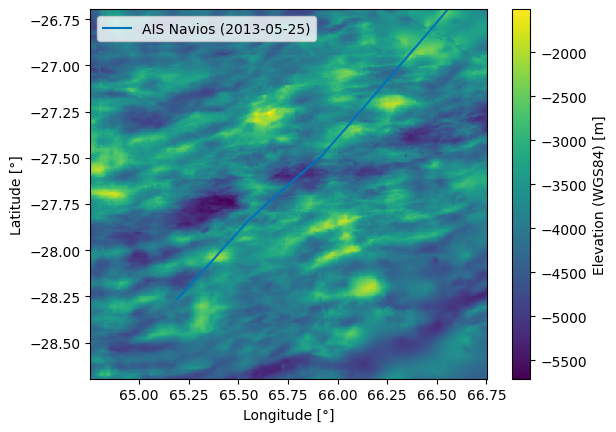

In [14]:
plt.figure()
ds_bathy.elevation.plot()
plt.contour(ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[0], colors='k')

days = np.unique(ais_navios.time.dt.date.values)[24:25]
for i, day in enumerate(days): 
    ais_day = ais_navios.sel(time=str(day))
    plt.plot(ais_day.lon, ais_day.lat, "-", label=f"AIS Navios ({str(day)})", color=color(i))
plt.legend()

### Coordonnées locales ENU 

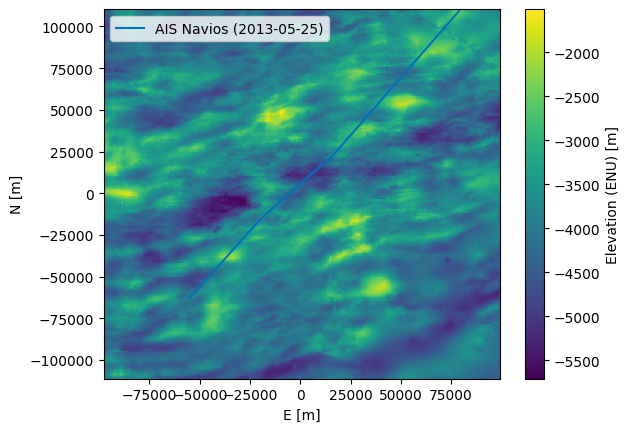

In [15]:
plt.figure()
ds_bathy.elevation_enu.plot()
plt.contour(
    ds_bathy.e,
    ds_bathy.n,
    ds_bathy.elevation_enu,
    levels=[5000, 4000, 3000, 2000],
    colors="k",
)

days = np.unique(ais_navios.time.dt.date.values)[24:25]
for i, day in enumerate(days):
    ais_day = ais_navios.sel(time=str(day))
    plt.plot(ais_day.e, ais_day.n, "-", label=f"AIS Navios ({str(day)})", color=color(i))
plt.legend()

### Trajectoire de tous les navires dans la zone (/ jour)

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_19808\1475949632.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


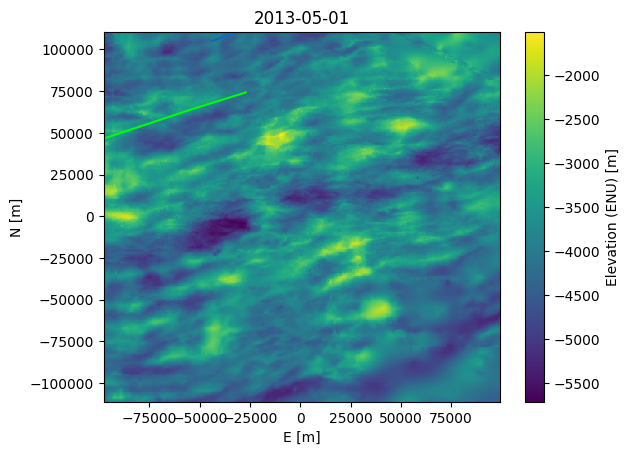

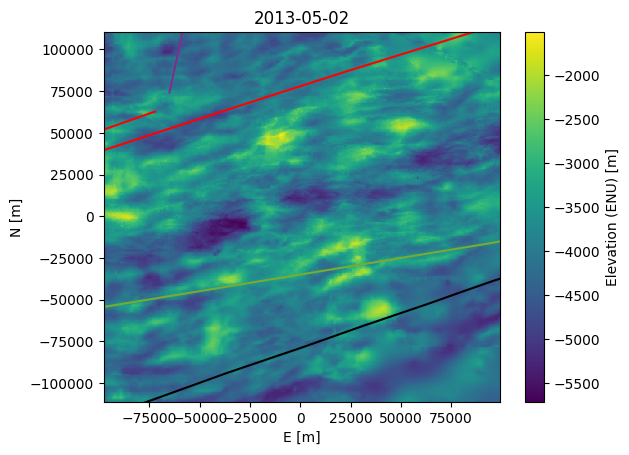

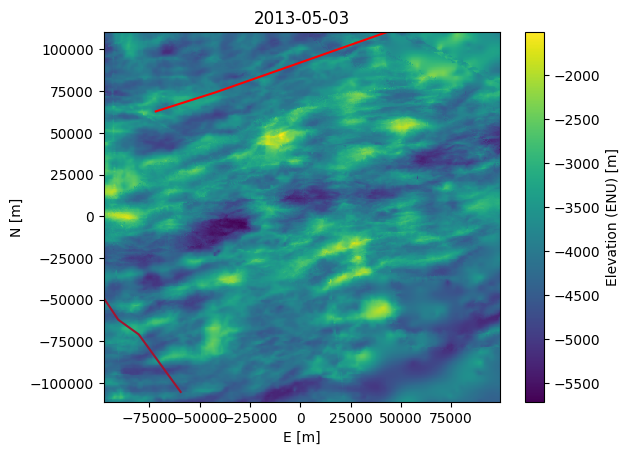

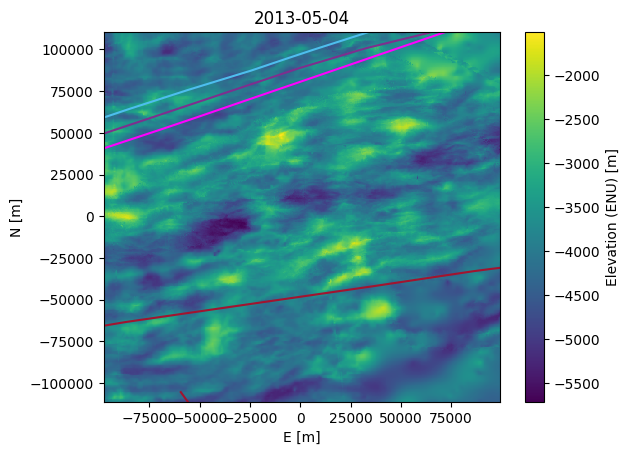

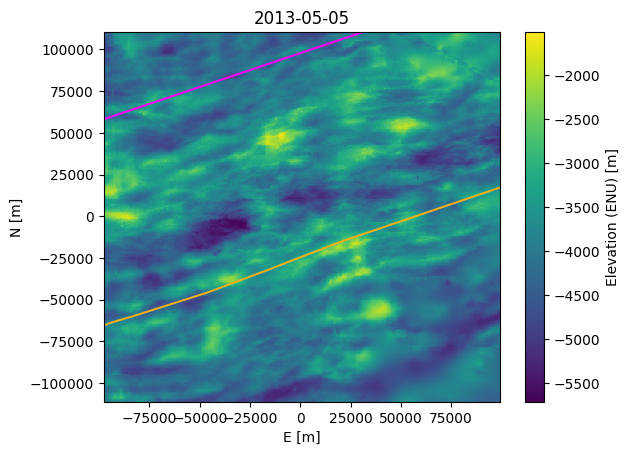

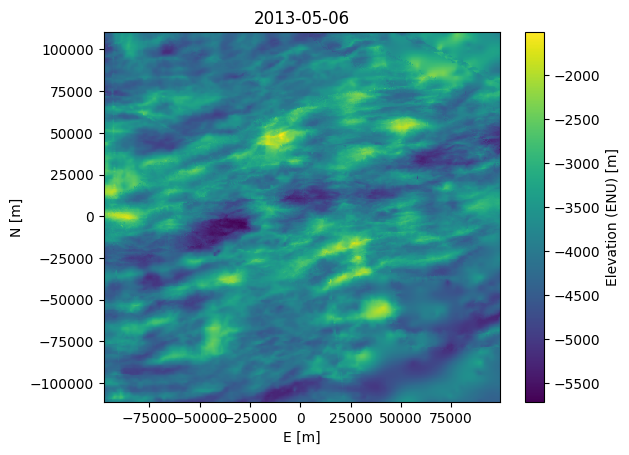

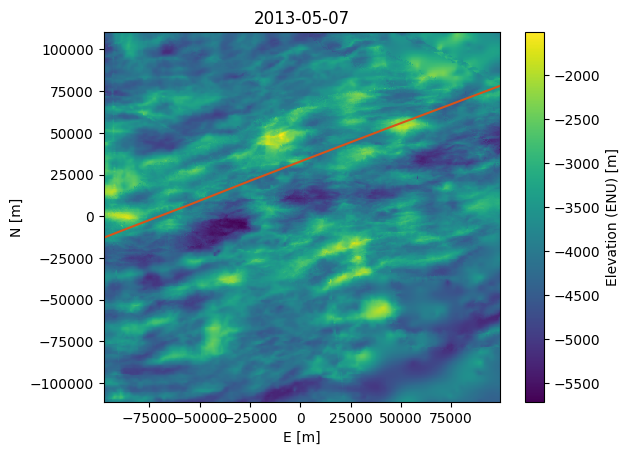

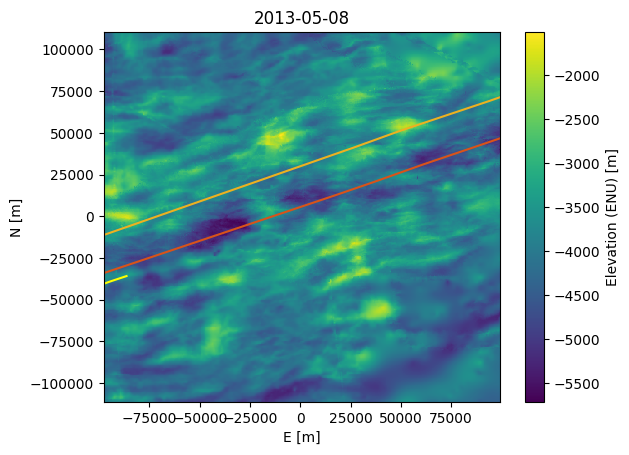

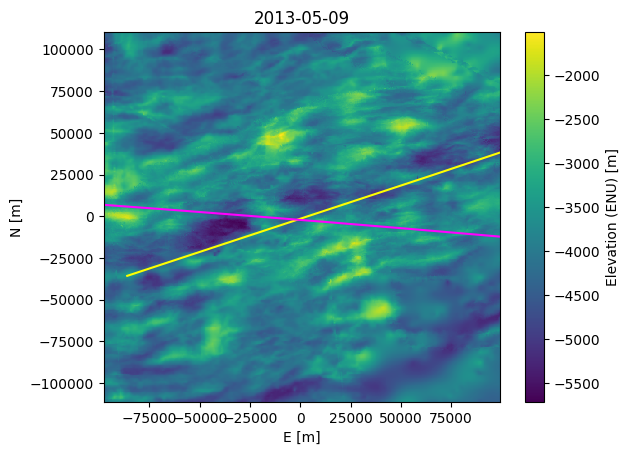

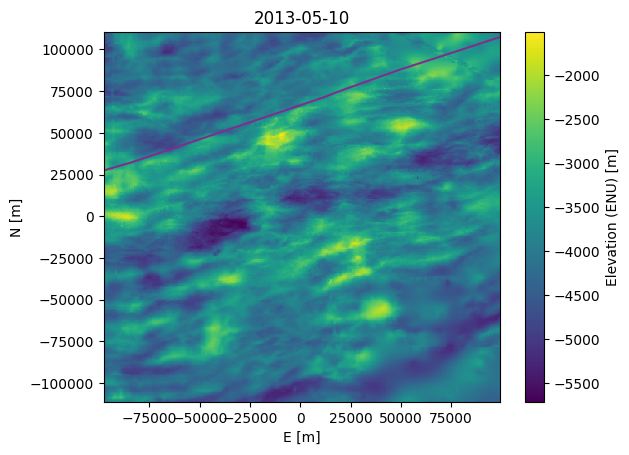

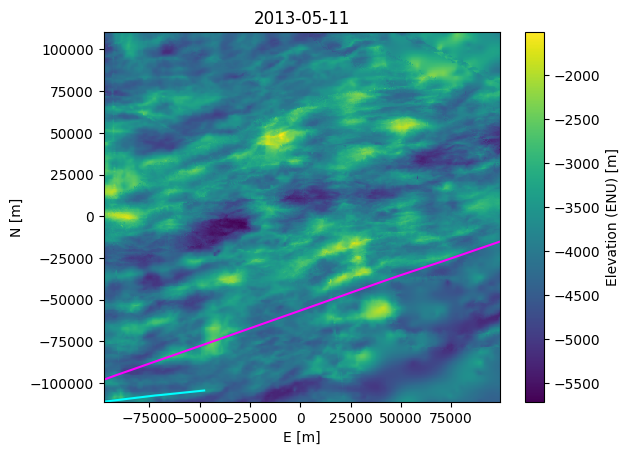

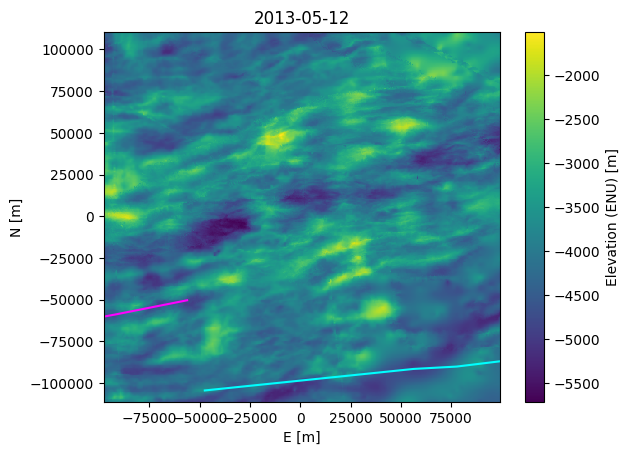

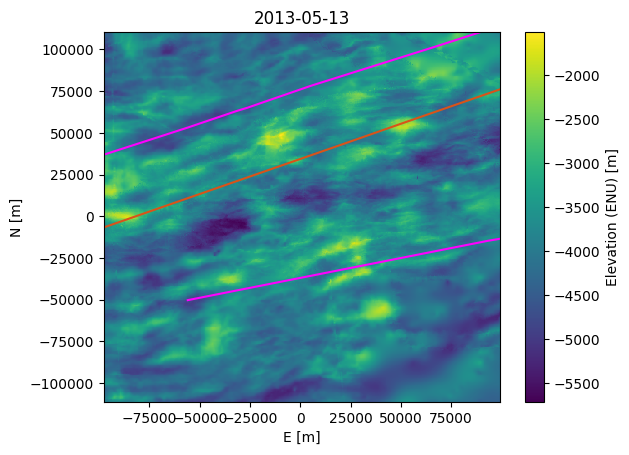

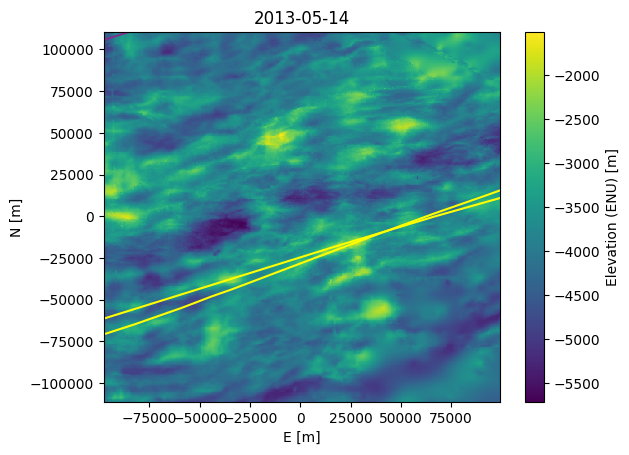

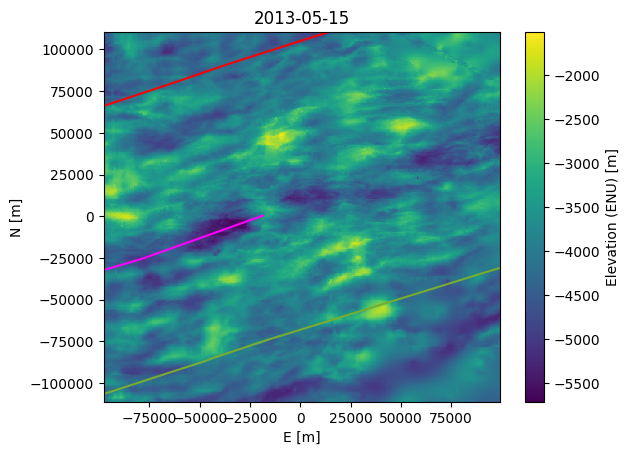

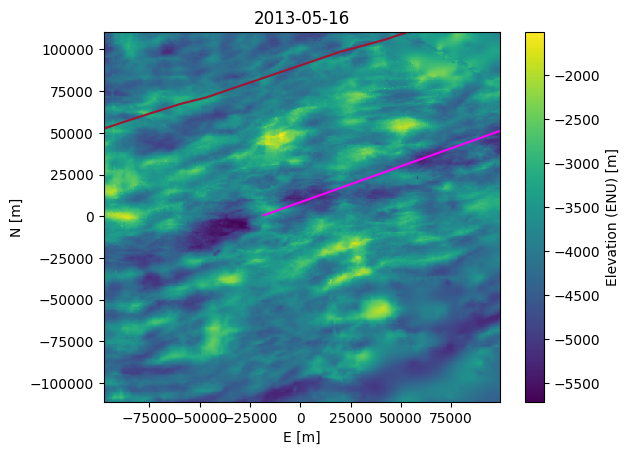

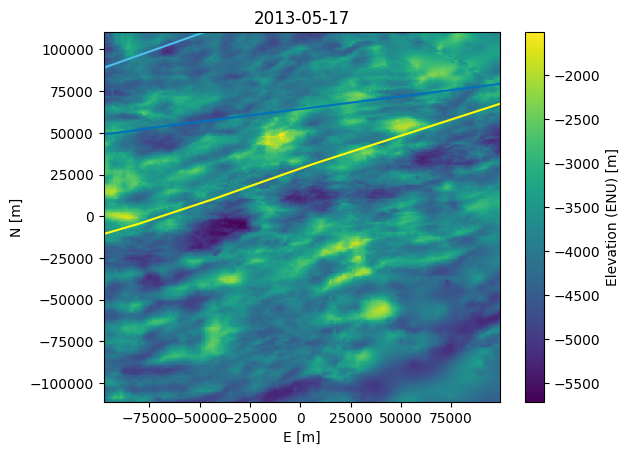

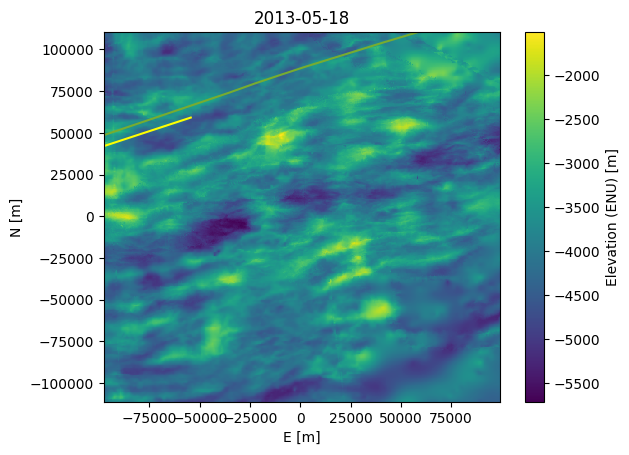

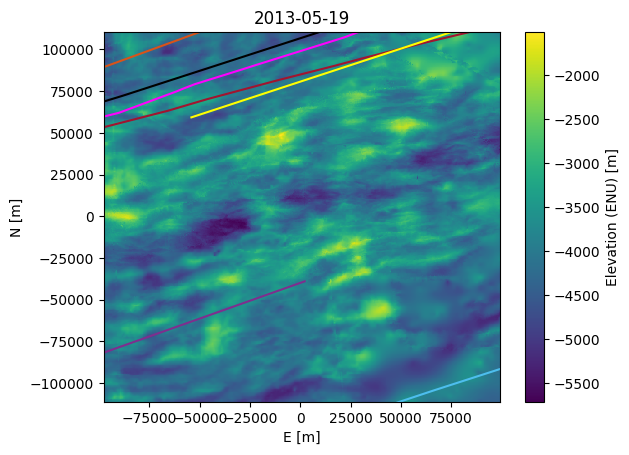

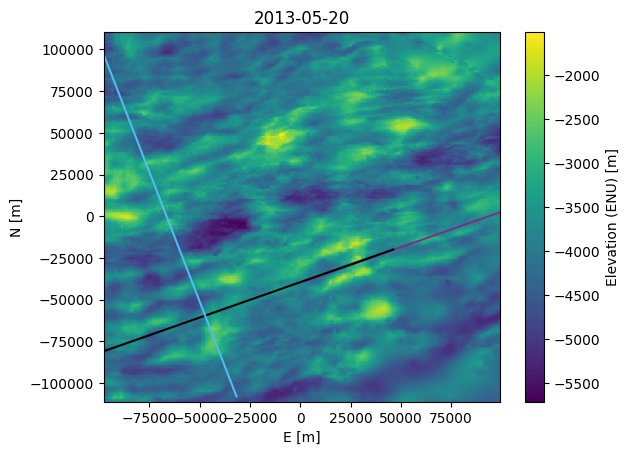

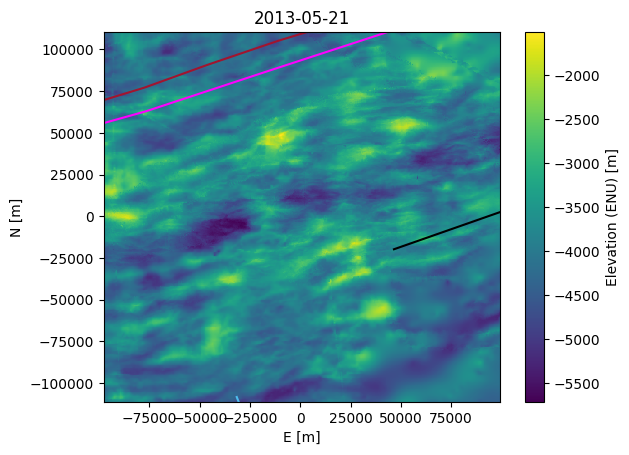

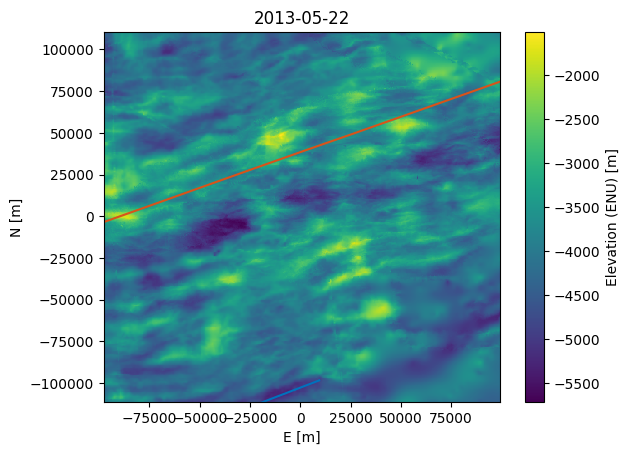

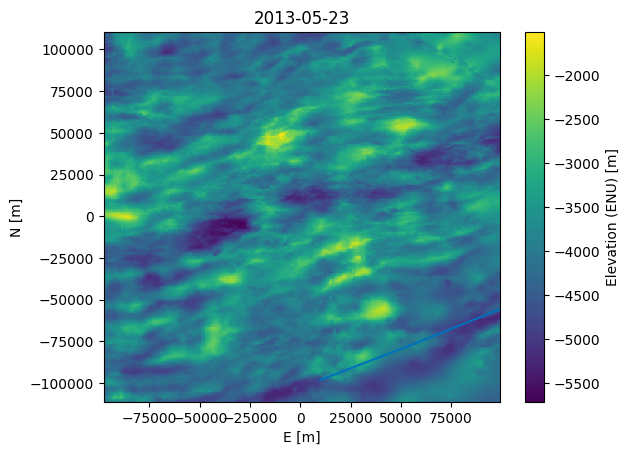

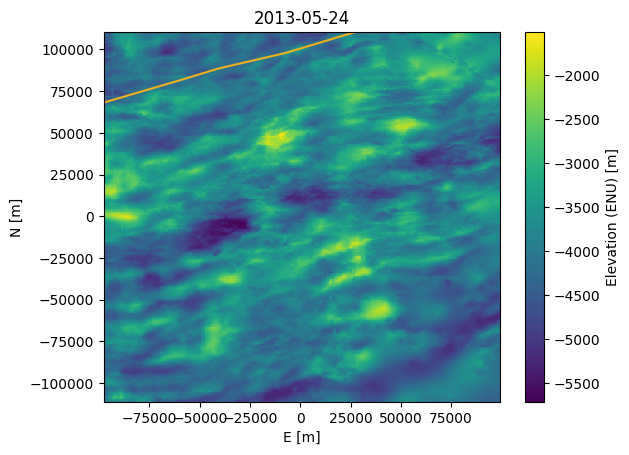

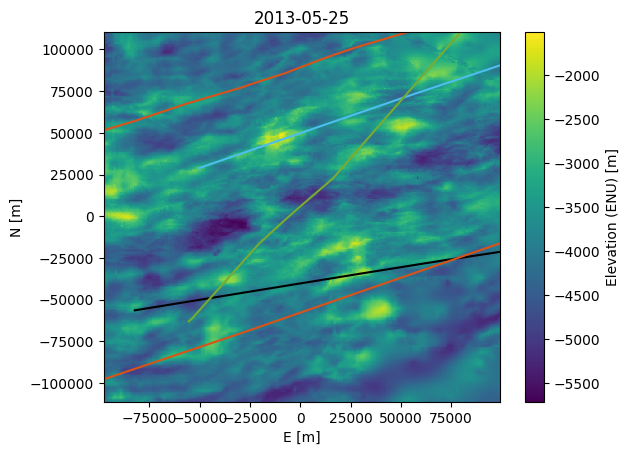

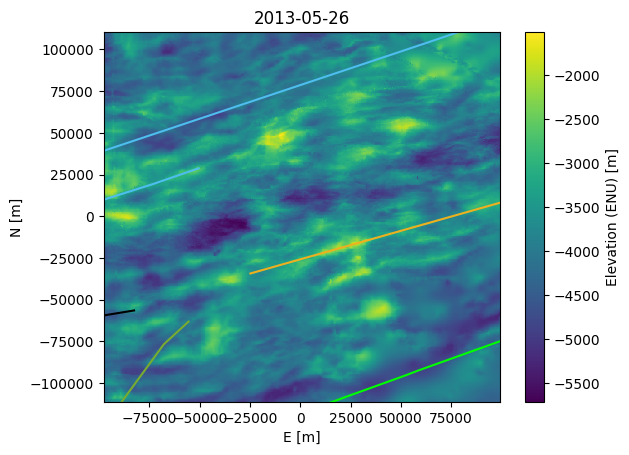

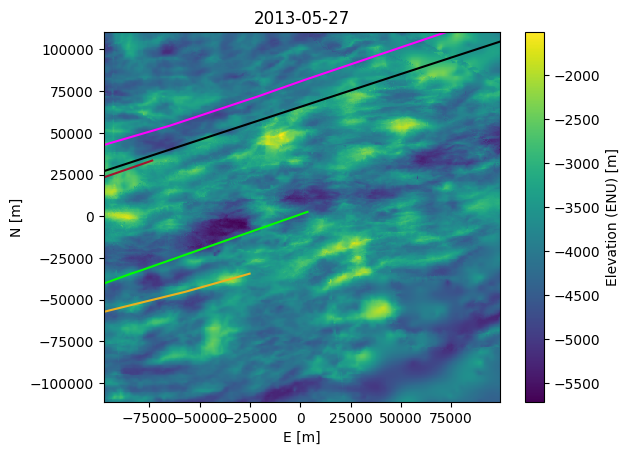

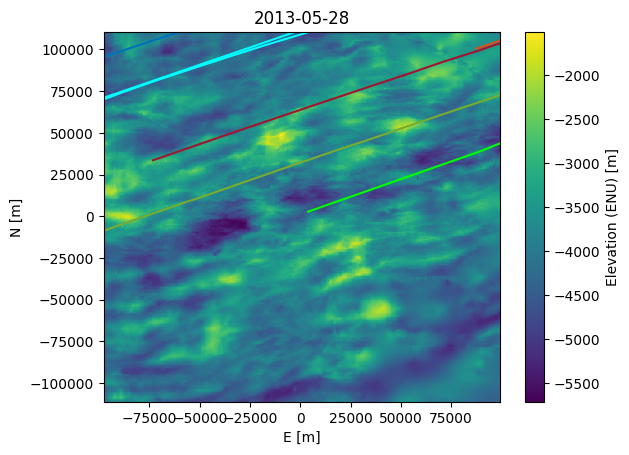

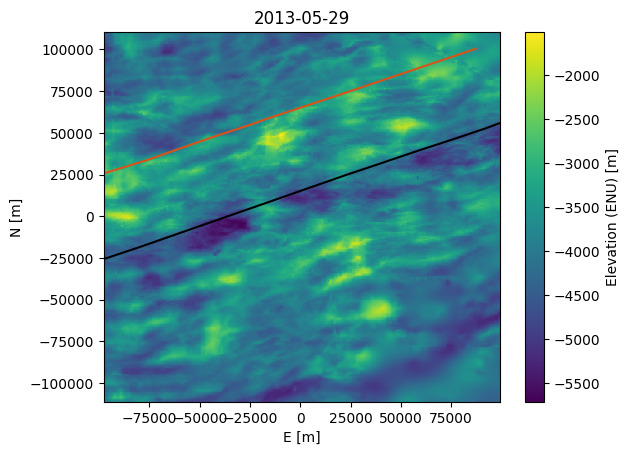

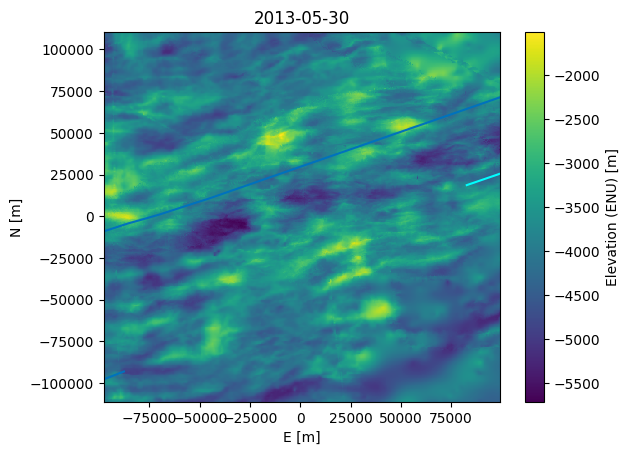

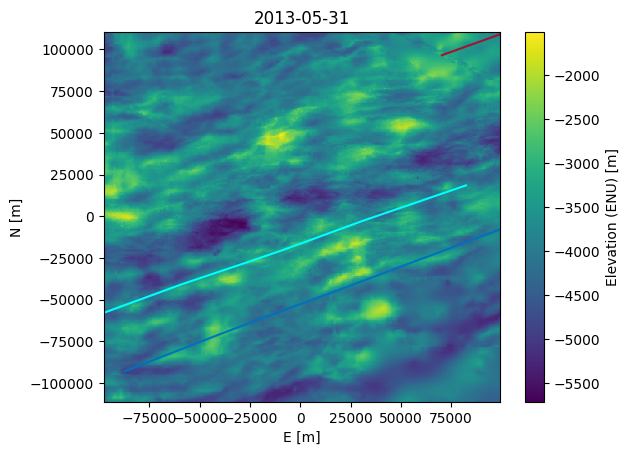

In [17]:
days = np.unique(ais_navios.time.dt.date.values)

for i, day in enumerate(days): 
    ais_day = ds_ais.sel(time=str(day))
    plt.figure()
    ds_bathy.elevation_enu.plot()
    plt.contour(ds_bathy.e, ds_bathy.n, ds_bathy.elevation_enu, levels=[5000, 4000, 3000, 2000], colors="k")

    for ii, mmsi_i in enumerate(ais_day.mmsi.values):
        ais_day_mmsi = ais_day.sel(mmsi=mmsi_i)
        plt.plot(
            ais_day_mmsi.e,
            ais_day_mmsi.n,
            "-",
            label=f"{mmsi_i}",
            color=color(ii),
        )
    plt.title(f"{str(day)}")
    # plt.legend()

### Évolution de la situation chaque heure 

In [10]:
# # Représentation sous forme de 24 vignettes de la situation AIS chaque heure
# # day = pd.to_datetime("2025-10-16").date()
# day = datetime.date(2025, 10, 13)
# # day = datetime.date(2025, 10, 15)
# # day = datetime.date(2025, 10, 16)


# ais_day = ds_ais.sel(time=str(day))

# fig, axs = plt.subplots(4, 6, figsize=(20, 15), sharex=True, sharey=True)
# fig.suptitle(f"AIS tracks on {str(day)}")

# axs = axs.flatten()
# hours = np.arange(0, 24)
# for i, hour in enumerate(hours):
#     ax = axs[i]
#     ds_bathy.elevation.plot(ax=ax, add_colorbar=False)
#     ax.contour(
#         ds_bathy.lon,
#         ds_bathy.lat,
#         ds_bathy.elevation,
#         levels=[0],
#         colors="k",
#     )

#     ais_hour = ais_day.isel(time=ais_day.time.dt.hour == hour)
#     for ii, mmsi_i in enumerate(ais_hour.mmsi.values):
#         ais_hour_mmsi = ais_hour.sel(mmsi=mmsi_i)
#         ax.plot(
#             ais_hour_mmsi.lon,
#             ais_hour_mmsi.lat,
#             "-",
#             label=f"{mmsi_i}",
#             color=color(ii),
#         )

#     # Add GPS track of Jules
#     gps_day = ds_gps.sel(time=str(day))
#     gps_hour = gps_day.isel(time=gps_day.time.dt.hour == hour)
#     ax.plot(
#         gps_hour.lon,
#         gps_hour.lat,
#         "o-",
#         label="Jules GPS",
#         color="black",
#         markersize=4,
#     )
#     ax.set_title(f"{hour:02d}h")

# Vitesses AIS 

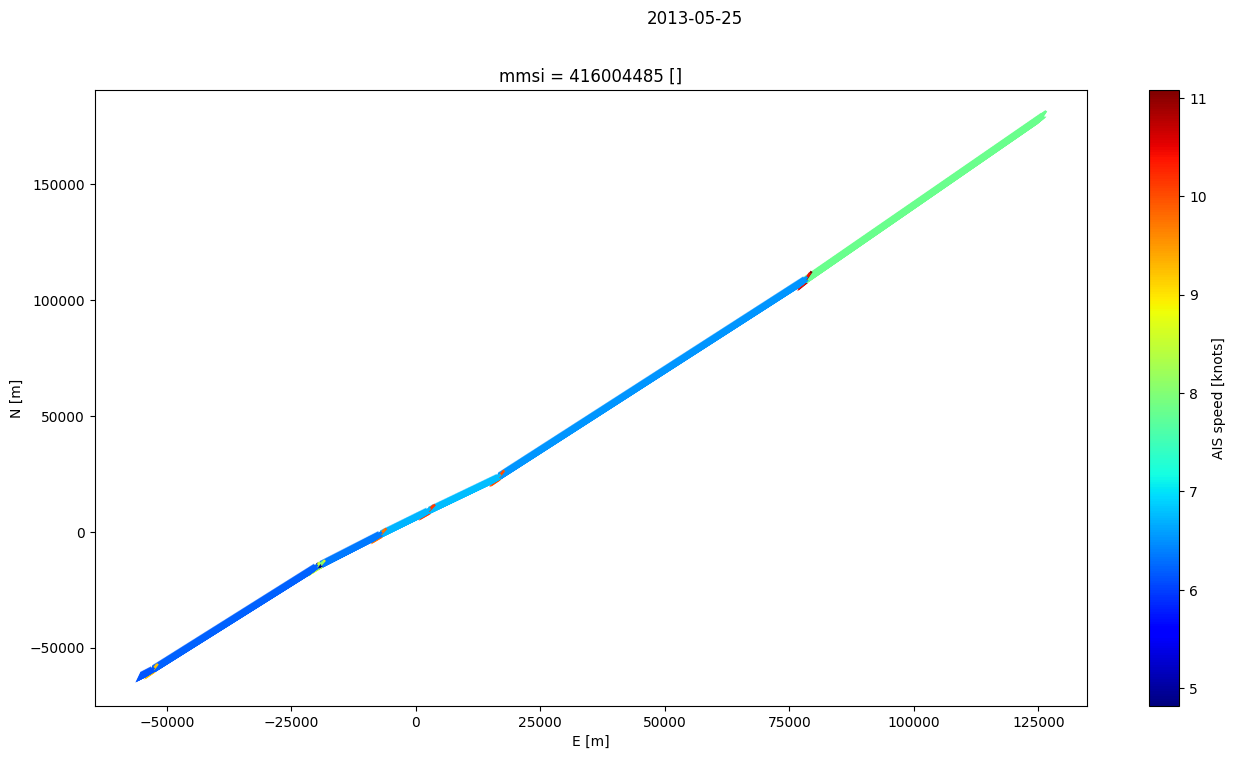

In [11]:
#  Visualise speed
days = np.unique(ais_navios.time.dt.date.values)[24:25]

for day in days:

    # AIS
    ais_day = ds_ais.sel(mmsi=mmsi_navios)
    ais_day = ais_day.sel(time=str(day))

    t_start = datetime.datetime.combine(day, datetime.time(11, 30, 0))
    t_end = datetime.datetime.combine(day, datetime.time(12, 30, 0))

    fig, axs = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
    fig.suptitle(f"{str(day)}")

    # ENU
    scale = None
    ais_day = ais_day.assign(speed=np.sqrt(ais_day.v_e**2 + ais_day.v_n**2) * 1.94384)
    q = ais_day.plot.quiver(
        x="e",
        y="n",
        u="v_e",
        v="v_n",
        hue="speed",
        ax=axs,
        cmap="jet",
        add_guide=False,
        scale=scale,
    )

    fig.colorbar(q, ax=axs, label="AIS speed [knots]")

